In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
#starting the connection
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [14]:
#creating table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")
conn.commit()

In [15]:
#inserting data
cursor.execute("DELETE FROM sales")

sales_data = [
    ("Laptop", 5, 50000),
    ("Phone", 10, 20000),
    ("Tablet", 7, 15000),
    ("Laptop", 3, 50000),
    ("Phone", 5, 20000)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sales_data)

conn.commit()

In [16]:
#sql query
query = """
SELECT product,
       SUM(quantity) AS total_qty,
       SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

df = pd.read_sql_query(query, conn)
df

,product,total_qty,revenue
0,Laptop,8,400000.0
1,Phone,15,300000.0
2,Tablet,7,105000.0


In [17]:
#s
print("Sales Summary:")
print(df)

Sales Summary:
  product  total_qty   revenue
0  Laptop          8  400000.0
1   Phone         15  300000.0
2  Tablet          7  105000.0


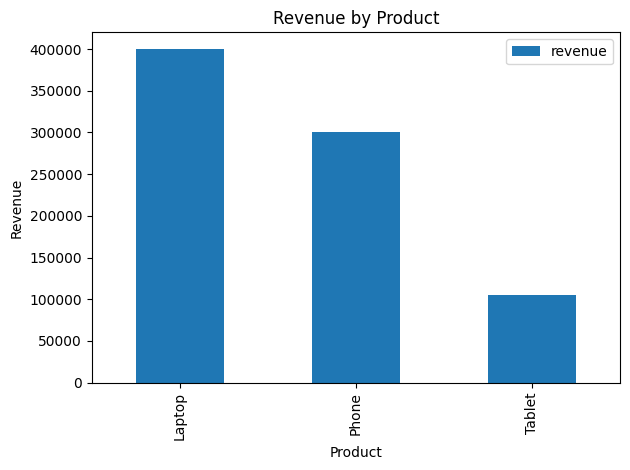

In [18]:
#plotting the product and revenue
df.plot(kind='bar', x='product', y='revenue')
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.xlabel("Product")
plt.tight_layout()
plt.show()

In [19]:
#closing the connection
conn.close()

In [20]:
plt.savefig("sales_chart.png")

<Figure size 640x480 with 0 Axes>